# Temas Tratados en el Trabajo Práctico 8

* Aprendizaje estadístico.

* Evolución de la verosimilitud de una hipótesis en función de observaciones.

* Aprendizaje no supervisado. Algoritmo K-means.

* Aprendizaje supervisado. Algoritmo Knn.

* Aprendizaje por refuerzo. Algoritmo Q-Learning.

## Ejercicios Teóricos

1. Un fabricante de tornillos vende cajas que contienen 1000 tornillos de cabeza redonda con tres tipos de recubrimiento electrolítico (cincado, cobre y níquel). Cada caja se rellena
con diferentes proporciones que pueden variar de la siguiente manera:

&emsp;&emsp;a: Todos los tornillos están recubiertos de níquel. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;b: El 70% de los tornillos están recubiertos de níquel, el 20% de cobre, el resto está cincado. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;c: El 50% de los tornillos están recubiertos de níquel, el 25% de cobre y el resto está cincado. 50 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;d: El 20 % de los tornillos están recubiertos de níquel, el 50% de cobre y el resto está cincado. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;e: Todos los tornillos están recubiertos de cobre. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;1.1 ¿Cuál es la distribución a priori sobre las hipótesis?

Definimos la variable aleatoria de hipótesis $H = {h_a, h_b, h_c, h_d, h_e}$ según la composición de la caja. La probabilidad a priori $P(h_i)$ corresponde a la proporción de cajas que se rellenan con cada combinación:

$h_a$ (100% Níquel, 0% Cobre): $P(h_a) = \frac{15}{100} = \mathbf{0.15}$

$h_b$ (70% Níquel, 20% Cobre, 10% Cincado): $P(h_b) = \frac{15}{100} = \mathbf{0.15}$

$h_c$ (50% Níquel, 25% Cobre, 25% Cincado): $P(h_c) = \frac{50}{100} = \mathbf{0.50}$

$h_d$ (20% Níquel, 50% Cobre, 30% Cincado): $P(h_d) = \frac{10}{100} = \mathbf{0.10}$

$h_e$ (100% Cobre): $P(h_e) = \frac{10}{100} = \mathbf{0.10}$

$$
\mathbf{P(H)} = \langle 0.15,  0.15,  0.50,  0.10,  0.10 \rangle
$$

&emsp;Considerando que los 10 primeros tornillos que se extraen de una caja de muestra son de cobre:

&emsp;&emsp;1.2 Calcule la probabilidad de cada hipótesis dado que los 10 primeros tornillos fueron de cobre.

**1. Primera iteración: Extracción del 1.er tornillo de cobre (**$\text{Cu}_1$**)**

Fórmula general:

$$
P(h_i \mid \text{Cu}_1) = \frac{P(\text{Cu} \mid h_i) \cdot P(h_i)}{P(\text{Cu}_1)}
$$

Donde el denominador $P(\text{Cu}_1)$ es la probabilidad total de sacar un tornillo de cobre en el primer intento:

$$
P(\text{Cu}_1) = P(\text{Cu} \mid h_a) \cdot P(h_a) + P(\text{Cu} \mid h_b) \cdot P(h_b) + P(\text{Cu} \mid h_c) \cdot P(h_c) + P(\text{Cu} \mid h_d) \cdot P(h_d) + P(\text{Cu} \mid h_e) \cdot P(h_e)
$$

**Sustituyendo los valores:**

$$
P(\text{Cu}_1) = (0.00 \times 0.15) + (0.20 \times 0.15) + (0.25 \times 0.50) + (0.50 \times 0.10) + (1.00 \times 0.10) = \mathbf{0.305}
$$

Calculamos para cada hipótesis:

- $P(h_a \mid \text{Cu}_1)$**:** $\frac{0.00 \times 0.15}{0.305} = \mathbf{0.000}$
- $P(h_b \mid \text{Cu}_1)$**:** $\frac{0.20 \times 0.15}{0.305} = \frac{0.030}{0.305} = \mathbf{0.098}$
- $P(h_c \mid \text{Cu}_1)$**:** $\frac{0.25 \times 0.50}{0.305} = \frac{0.125}{0.305} = \mathbf{0.410}$
- $P(h_d \mid \text{Cu}_1)$**:** $\frac{0.50 \times 0.10}{0.305} = \frac{0.050}{0.305} = \mathbf{0.164}$
- $P(h_e \mid \text{Cu}_1)$**:** $\frac{1.00 \times 0.10}{0.305} = \frac{0.100}{0.305} = \mathbf{0.328}$


**2. Segunda iteración: Extracción del 2.º tornillo de cobre (**$\text{Cu}_2$**)**

Para la segunda extracción, la probabilidad a posteriori previa pasa a ser la nueva probabilidad previa. La fórmula es:

$$
P(h_i \mid \text{Cu}_1, \text{Cu}_2) = \frac{P(\text{Cu} \mid h_i) \cdot P(h_i \mid \text{Cu}_1)}{P(\text{Cu}_2 \mid \text{Cu}_1)}
$$

Donde el denominador $P(\text{Cu}_2 \mid \text{Cu}_1)$ es la probabilidad marginal de que el segundo tornillo sea de cobre habiendo salido el primero de cobre:

$$
P(\text{Cu}_2 \mid \text{Cu}_1) = P(\text{Cu} \mid h_a) \cdot P(h_a \mid \text{Cu}_1) + P(\text{Cu} \mid h_b) \cdot P(h_b \mid \text{Cu}_1) + P(\text{Cu} \mid h_c) \cdot P(h_c \mid \text{Cu}_1) + P(\text{Cu} \mid h_d) \cdot P(h_d \mid \text{Cu}_1) + P(\text{Cu} \mid h_e) \cdot P(h_e \mid \text{Cu}_1)
$$

**Sustituyendo los valores del paso 1:**

$$
P(\text{Cu}_2 \mid \text{Cu}_1) = (0.00 \times 0.000) + (0.20 \times 0.098) + (0.25 \times 0.410) + (0.50 \times 0.164) + (1.00 \times 0.328) = \mathbf{0.532}
$$

Calculamos para cada hipótesis:

- $P(h_a \mid \text{Cu}_1, \text{Cu}_2)$**:** $\frac{0.00 \times 0.000}{0.532} = \mathbf{0.000}$
- $P(h_b \mid \text{Cu}_1, \text{Cu}_2)$**:** $\frac{0.20 \times 0.098}{0.532} = \frac{0.0196}{0.532} = \mathbf{0.037}$
- $P(h_c \mid \text{Cu}_1, \text{Cu}_2)$**:** $\frac{0.25 \times 0.410}{0.532} = \frac{0.1025}{0.532} = \mathbf{0.193}$
- $P(h_d \mid \text{Cu}_1, \text{Cu}_2)$**:** $\frac{0.50 \times 0.164}{0.532} = \frac{0.0820}{0.532} = \mathbf{0.154}$
- $P(h_e \mid \text{Cu}_1, \text{Cu}_2)$**:** $\frac{1.00 \times 0.328}{0.532} = \frac{0.3280}{0.532} = \mathbf{0.616}$

Realizamos este procedimiento hasta sacar los 10 tornillos de Cobre.

**4. Resultado final tras la 10.ª iteración (Tabla)**

| $h_i$ | $P(\text{cobre} \mid h_i)$ | $P \text{ priori } P(h_i)$ | $P(h_i \mid d_1)$ | $P(h_i \mid d_2)$ | $P(h_i \mid d_3)$ | $P(h_i \mid d_4)$ | $P(h_i \mid d_5)$ | $P(h_i \mid d_6)$ | $P(h_i \mid d_7)$ | $P(h_i \mid d_8)$ | $P(h_i \mid d_9)$ | $P(h_i \mid d_{10})$ |
|:-----:|--------------------------:|---------------------------:|------------------:|------------------:|------------------:|------------------:|------------------:|------------------:|------------------:|------------------:|------------------:|---------------------:|
| **a** | 0.000 | 0.150 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 |
| **b** | 0.200 | 0.150 | 0.098 | 0.037 | 0.010 | 0.002 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 | 0.000 |
| **c** | 0.250 | 0.500 | 0.410 | 0.193 | 0.064 | 0.018 | 0.005 | 0.001 | 0.000 | 0.000 | 0.000 | 0.000 |
| **d** | 0.500 | 0.100 | 0.164 | 0.154 | 0.103 | 0.058 | 0.030 | 0.015 | 0.008 | 0.004 | 0.002 | 0.001 |
| **e** | 1.000 | 0.100 | 0.328 | 0.616 | 0.823 | 0.922 | 0.965 | 0.983 | 0.992 | 0.996 | 0.998 | **0.999** |
| | **$P(D)$** | | **0.305** | **0.532** | **0.749** | **0.892** | **0.956** | **0.981** | **0.991** | **0.996** | **0.998** | **0.999** |



&emsp;&emsp;1.3 Grafique la evolución de la verosimilitud de cada hipótesis en función del número de tornillos extraídos de la caja.

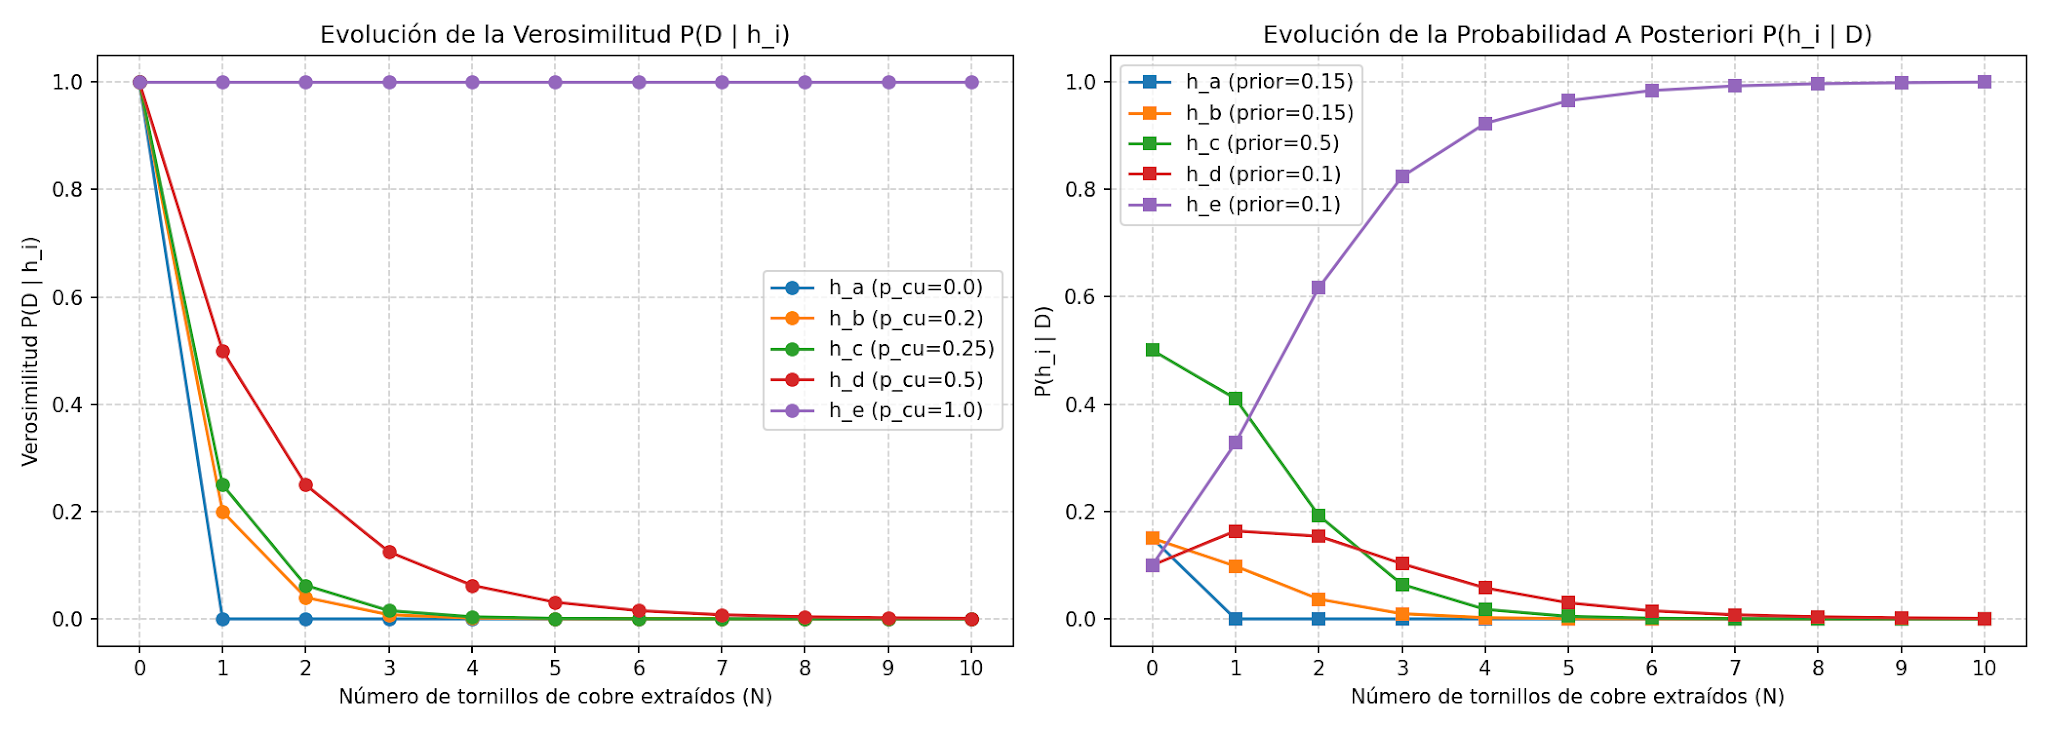
Comportamiento de la Verosimilitud $P(D \mid h_i)$: Para la hipótesis $h_e$, la verosimilitud se mantiene constante en $1.0$. Para las demás hipótesis, decae exponencialmente conforme aumenta el número $N$ de extracciones de cobre.

Comportamiento de la Probabilidad A Posteriori $P(h_i \mid D)$: Comienza en la distribución a priori ($N=0$). Con $N=1$ y $N=2$, las hipótesis $h_c$ y $h_d$ retienen cierta probabilidad, pero a partir de $N \ge 3$, la hipótesis $h_e$ domina completamente la probabilidad acumulada.

&emsp;&emsp;1.4 Para cada hipótesis, ¿cuál es la probabilidad de que el cuarto tornillo extraído sea de cobre?

Si con "el cuarto tornillo" se refieren al evento de sacar 4 tornillos de cobre de forma consecutiva ($P(\text{Cu})^4$) para cada caja $h_i$:

**$h_a$:** $0^4 = \mathbf{0} \quad (0\%)$

**$h_b$:** $0.20^4 = 0.0016 \quad (\mathbf{0.16\%})$

**$h_c$:** $0.25^4 = 0.00390625 \quad (\mathbf{0.39\%})$

**$h_d$:** $0.50^4 = 0.0625 \quad (\mathbf{6.25\%})$

**$h_e$:** $1.00^4 = 1.00 \quad (\mathbf{100\%})$


2. ¿Qué diferencia principal existe entre un algoritmo supervisado y un algoritmo no supervisado? Estudiar bien para el final

La diferencia principal está en si el algoritmo aprende utilizando datos etiquetados o no etiquetados:
* Aprendizaje supervisado: el algoritmo recibe datos de entrada junto con la respuesta correcta (etiqueta). Aprende la relación entre ambos para luego predecir resultados sobre datos nuevos.
Ejemplo: clasificar correos como spam o no spam usando correos previamente etiquetados.

* Aprendizaje no supervisado: el algoritmo recibe datos sin etiquetas y debe encontrar por sí mismo patrones, grupos o relaciones dentro de ellos.
Ejemplo: agrupar clientes según sus hábitos de compra sin haber definido previamente los grupos.

|Característica|Aprendizaje Supervisado|Aprendizaje No Supervisado|
|---|---|---|
|Datos de entrenamiento|Etiquetados. Incluyen tanto la entrada (features) como la salida deseada (target).|"No etiquetados. Solo incluyen los datos de entrada, sin respuestas provistas."|
|Objetivo|Predecir o clasificar. Aprender una función matemática que mapee correctamente las entradas a las salidas.|"Descubrir estructuras. Encontrar patrones ocultos, agrupaciones o relaciones intrínsecas en los datos."|
|Mecanismo de ajuste|Minimiza una función de pérdida (loss function) midiendo la diferencia entre su predicción y la etiqueta real.|Optimiza métricas internas (como la distancia espacial entre puntos o la varianza retenida) al no tener una respuesta correcta contra la cual compararse.|
|Ejemplos clásicos|"Regresión Lineal, Máquinas de Vectores de Soporte (SVM), Random Forest."|"K-Means (Clustering), Análisis de Componentes Principales (PCA), DBSCAN."|

## Ejercicios de implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

3. Genere un conjunto de 23 puntos que contengan coordenadas *xy* aleatorias con valores contenidos en el intervalo [0, 5] y grafique los puntos obtenidos en un gráfico.

&emsp;&emsp;3.1 Implemente un algoritmo K-means que clasifique 20 de los puntos en 2 grupos y grafique el resultado asignando un color a cada uno.


&emsp;&emsp;3.2 Tome los tres puntos restantes y clasifíquelos en los grupos obtenidos anteriormente usando el algoritmo Knn. Utilice distintos valores de K y anote lo que observa con esta elección.

Se generaron 23 puntos aleatorios en [0, 5].


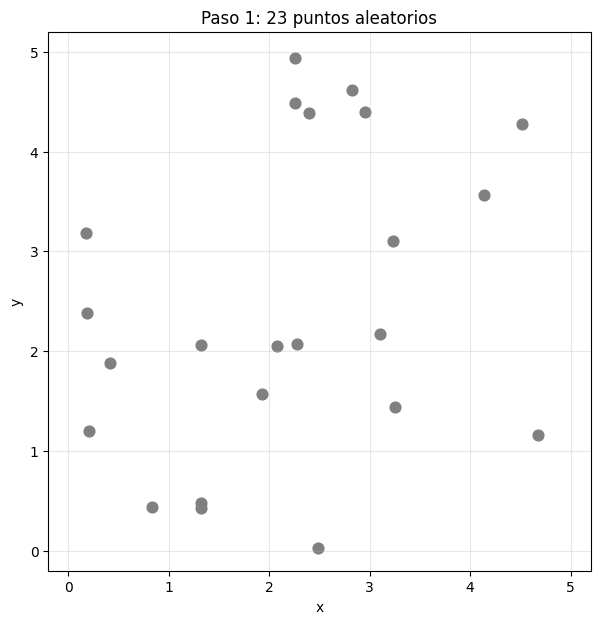


=== Centroides iniciales ===
Ingresá cada centroide como 'x y' (valores entre 0 y 5).
Presioná Enter sin escribir nada para elegir uno al azar.

  -> aleatorio: (2.398, 4.388)
  -> aleatorio: (1.325, 2.058)


K-Means convergió en 2 iteraciones (sobre 20 puntos).
  Centroide final 0: (3.050, 4.381)  -> 7 puntos
  Centroide final 1: (1.369, 1.478)  -> 13 puntos

Puntos a clasificar con KNN (más cercanos a la equidistancia):
  P1 (3.11, 2.18)  d0=2.206  d1=1.871  distancia a la frontera=0.203
  P2 (4.67, 1.16)  d0=3.604  d1=3.319  distancia a la frontera=0.294
  P3 (3.23, 3.10)  d0=1.290  d1=2.471  distancia a la frontera=0.662

Valores de K a evaluar: [1, 3, 5, 6, 9]

--- K = 1 ---
  P1 (3.11, 2.18) -> Grupo 1 (Azul)   [votos: Rojo=0, Azul=1]
  P2 (4.67, 1.16) -> Grupo 1 (Azul)   [votos: Rojo=0, Azul=1]
  P3 (3.23, 3.10) -> Grupo 0 (Rojo)   [votos: Rojo=1, Azul=0]

--- K = 3 ---
  P1 (3.11, 2.18) -> Grupo 1 (Azul)   [votos: Rojo=0, Azul=3]
  P2 (4.67, 1.16) -> Grupo 1 (Azul)   [votos: R

In [1]:
"""
K-Means (20 puntos, 2 grupos) + KNN (3 puntos restantes, K en [1, 3, 5, 6, 9]).

Los 3 puntos que se clasifican con KNN pueden elegirse de dos maneras
(pregunta S/n, por defecto Sí):
  - Sí: los 3 puntos más cercanos a ser equidistantes de ambos centroides
        (los más "ambiguos"), para que el efecto de K se note más.
  - No: simplemente los 3 últimos puntos generados.

K-Means y KNN están implementados desde cero con NumPy (sin sklearn).
Requisitos: pip install numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------------------------------- #
# Generación de datos
# --------------------------------------------------------------------------- #
class PointGenerator:
    """Genera puntos 2D aleatorios en el intervalo [low, high]."""

    def __init__(self, n_points=23, low=0.0, high=5.0, seed=None):
        self.n_points = n_points
        self.low = low
        self.high = high
        self.rng = np.random.default_rng(seed)

    def generate(self):
        return self.rng.uniform(self.low, self.high, size=(self.n_points, 2))


# --------------------------------------------------------------------------- #
# K-Means
# --------------------------------------------------------------------------- #
class KMeans:
    """Implementación de K-Means (algoritmo de Lloyd)."""

    def __init__(self, n_clusters=2, max_iter=300, tol=1e-9):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.centroids = None
        self.labels_ = None
        self.n_iter_ = 0

    @staticmethod
    def distances(X, centroids):
        """Matriz (n_puntos x n_centroides) de distancias euclídeas."""
        return np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)

    def fit(self, X, initial_centroids):
        X = np.asarray(X, dtype=float)
        centroids = np.array(initial_centroids, dtype=float)

        for i in range(1, self.max_iter + 1):
            # 1) Asignación: cada punto al centroide más cercano
            labels = np.argmin(self.distances(X, centroids), axis=1)

            # 2) Actualización: nuevo centroide = media del grupo
            new_centroids = centroids.copy()
            for k in range(self.n_clusters):
                members = X[labels == k]
                if len(members) > 0:          # si un grupo queda vacío, se conserva
                    new_centroids[k] = members.mean(axis=0)

            # 3) Convergencia
            shift = np.linalg.norm(new_centroids - centroids)
            centroids = new_centroids
            self.n_iter_ = i
            if shift <= self.tol:
                break

        self.centroids = centroids
        self.labels_ = np.argmin(self.distances(X, centroids), axis=1)
        return self


# --------------------------------------------------------------------------- #
# KNN
# --------------------------------------------------------------------------- #
class KNNClassifier:
    """Clasificador K-Nearest Neighbors (distancia euclídea, voto por mayoría)."""

    def __init__(self):
        self.X = None
        self.y = None

    def fit(self, X, y):
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y, dtype=int)
        return self

    def predict_one(self, point, k):
        """
        Devuelve (etiqueta, índices_vecinos, distancias_vecinos).
        Desempate (posible con K par, ej. K=6 con 3 vs 3):
        gana el grupo cuya suma de distancias a sus vecinos sea menor.
        """
        dists = np.linalg.norm(self.X - point, axis=1)
        idx = np.argsort(dists)[:k]
        neighbor_labels = self.y[idx]

        classes, counts = np.unique(neighbor_labels, return_counts=True)
        winners = classes[counts == counts.max()]

        if len(winners) == 1:
            label = winners[0]
        else:
            sums = {c: dists[idx][neighbor_labels == c].sum() for c in winners}
            label = min(sums, key=sums.get)

        return int(label), idx, dists[idx]


# --------------------------------------------------------------------------- #
# Visualización
# --------------------------------------------------------------------------- #
class Plotter:
    """Se encarga de todos los gráficos."""

    COLORS = {0: "red", 1: "blue"}
    NAMES = {0: "Grupo 0 (Rojo)", 1: "Grupo 1 (Azul)"}

    def __init__(self):
        plt.ion()
        self.fig, self.ax = plt.subplots(figsize=(7, 7))

    def _setup(self, title):
        self.ax.clear()
        self.ax.set_xlim(-0.2, 5.2)
        self.ax.set_ylim(-0.2, 5.2)
        self.ax.set_xlabel("x")
        self.ax.set_ylabel("y")
        self.ax.set_title(title)
        self.ax.grid(True, alpha=0.3)

    def _refresh(self):
        self.fig.canvas.draw_idle()
        plt.pause(0.1)

    def _draw_groups(self, X, labels):
        for k, color in self.COLORS.items():
            pts = X[labels == k]
            self.ax.scatter(pts[:, 0], pts[:, 1], c=color, s=60,
                            label=self.NAMES[k], alpha=0.8)

    def _draw_centroids(self, centroids):
        for k, c in enumerate(centroids):
            self.ax.scatter(c[0], c[1], c=self.COLORS[k], marker="X", s=250,
                            edgecolors="black", linewidths=1.5,
                            label=f"Centroide {k}")

    def _draw_boundary(self, centroids):
        """Mediatriz entre los dos centroides: puntos equidistantes."""
        c0, c1 = centroids
        v = c1 - c0
        norm = np.linalg.norm(v)
        if norm < 1e-12:
            return
        mid = (c0 + c1) / 2
        direction = np.array([-v[1], v[0]]) / norm
        t = np.array([-10.0, 10.0])
        line = mid[None, :] + t[:, None] * direction[None, :]
        self.ax.plot(line[:, 0], line[:, 1], "k--", linewidth=1, alpha=0.6,
                     label="Equidistancia entre centroides")

    def _draw_pending(self, pending):
        self.ax.scatter(pending[:, 0], pending[:, 1], c="black", marker="*",
                        s=250, label="Puntos sin clasificar")
        for i, p in enumerate(pending):
            self.ax.annotate(f"P{i + 1}", p, textcoords="offset points",
                             xytext=(8, 8), fontweight="bold")

    def show_raw(self, X):
        self._setup("Paso 1: 23 puntos aleatorios")
        self.ax.scatter(X[:, 0], X[:, 1], c="gray", s=60)
        self._refresh()

    def show_kmeans(self, X_train, labels, centroids, pending, n_iter):
        self._setup(f"Paso 2: K-Means (2 grupos, {n_iter} iteraciones)")
        self._draw_groups(X_train, labels)
        self._draw_centroids(centroids)
        self._draw_boundary(centroids)
        self._draw_pending(pending)
        self.ax.legend(loc="upper right", fontsize=8)
        self._refresh()

    def show_knn(self, X_train, y_train, centroids, pending, pred_labels,
                 neighbors, k):
        self._setup(f"Paso 3: KNN con K = {k}")
        self._draw_groups(X_train, y_train)
        self._draw_boundary(centroids)
        for i, p in enumerate(pending):
            color = self.COLORS[pred_labels[i]]
            # líneas hacia los K vecinos usados
            for j in neighbors[i]:
                self.ax.plot([p[0], X_train[j, 0]], [p[1], X_train[j, 1]],
                             color=color, alpha=0.35, linewidth=1)
            self.ax.scatter(p[0], p[1], c=color, marker="*", s=350,
                            edgecolors="black", linewidths=1.5)
            self.ax.annotate(f"P{i + 1}", p, textcoords="offset points",
                             xytext=(10, 10), fontweight="bold")
        self.ax.legend(loc="upper right", fontsize=8)
        self._refresh()


# --------------------------------------------------------------------------- #
# Aplicación principal
# --------------------------------------------------------------------------- #
class Application:
    N_POINTS = 23
    N_TRAIN = 20
    N_CLUSTERS = 2
    K_VALUES = [1, 3, 5, 6, 9]

    def __init__(self, seed=None):
        self.points = PointGenerator(self.N_POINTS, 0, 5, seed).generate()
        self.X_train = None      # 20 puntos -> K-Means
        self.X_pending = None    # 3 puntos  -> KNN
        self.plotter = Plotter()
        self.rng = np.random.default_rng(seed)

    # ---- entradas por consola -------------------------------------------- #
    def _ask_centroids(self):
        print("\n=== Centroides iniciales ===")
        print("Ingresá cada centroide como 'x y' (valores entre 0 y 5).")
        print("Presioná Enter sin escribir nada para elegir uno al azar.\n")

        centroids = []
        for k in range(self.N_CLUSTERS):
            while True:
                raw = input(f"Centroide {k} (x y): ").strip().replace(",", " ")
                if raw == "":
                    c = self.points[self.rng.integers(len(self.points))]
                    print(f"  -> aleatorio: ({c[0]:.3f}, {c[1]:.3f})")
                    centroids.append(c)
                    break
                try:
                    x, y = map(float, raw.split())
                    centroids.append(np.array([x, y]))
                    break
                except ValueError:
                    print("  Entrada inválida. Ejemplo: 1.5 3.2")
        return np.array(centroids)

    @staticmethod
    def _ask_yes_no(prompt, default=True):
        hint = "[S/n]" if default else "[s/N]"
        while True:
            raw = input(f"{prompt} {hint}: ").strip().lower()
            if raw == "":
                return default
            if raw in ("s", "si", "sí", "y", "yes"):
                return True
            if raw in ("n", "no"):
                return False
            print("  Respondé con S o N (Enter = opción predefinida).")

    # ---- división entrenamiento / pendientes ------------------------------ #
    @staticmethod
    def _boundary_distance(points, centroids):
        """Distancia de cada punto a la mediatriz entre los dos centroides
        (0 = perfectamente equidistante)."""
        c0, c1 = centroids
        d0 = np.linalg.norm(points - c0, axis=1)
        d1 = np.linalg.norm(points - c1, axis=1)
        sep = max(np.linalg.norm(c1 - c0), 1e-12)
        return np.abs(d0 ** 2 - d1 ** 2) / (2 * sep)

    def _split_default(self, init):
        """20 primeros puntos -> K-Means, 3 últimos -> KNN."""
        train = self.points[:self.N_TRAIN]
        pending = self.points[self.N_TRAIN:]
        km = KMeans(self.N_CLUSTERS).fit(train, init)
        return train, pending, km, True

    def _split_by_ambiguity(self, init, max_rounds=20):
        """
        Elige como pendientes los puntos más cercanos a la equidistancia.
        Como los centroides dependen de los puntos de entrenamiento, se itera
        hasta que la selección sea estable:
          1) K-Means con los 23 puntos -> centroides provisorios
          2) se separan los 3 puntos más cercanos a la frontera
          3) K-Means con los 20 restantes -> centroides nuevos
          4) se repite desde 2) hasta que los 3 puntos no cambien
        Devuelve (X_train, X_pending, kmeans_final, estable).
        """
        n_pending = self.N_POINTS - self.N_TRAIN
        km = KMeans(self.N_CLUSTERS).fit(self.points, init)
        pending_idx, stable = None, False

        for _ in range(max_rounds):
            gap = self._boundary_distance(self.points, km.centroids)
            new_idx = np.argsort(gap)[:n_pending]      # el más ambiguo primero
            if pending_idx is not None and set(new_idx) == set(pending_idx):
                stable = True
                break
            pending_idx = new_idx
            mask = np.ones(self.N_POINTS, dtype=bool)
            mask[pending_idx] = False
            km = KMeans(self.N_CLUSTERS).fit(self.points[mask], init)

        mask = np.ones(self.N_POINTS, dtype=bool)
        mask[pending_idx] = False
        return self.points[mask], self.points[pending_idx], km, stable

    # ---- flujo del programa ---------------------------------------------- #
    def run(self):
        # 1) Puntos
        print(f"Se generaron {self.N_POINTS} puntos aleatorios en [0, 5].")
        self.plotter.show_raw(self.points)
        input("\n[Enter] para ejecutar K-Means...")

        # 2) Configuración + K-Means sobre 20 puntos
        init = self._ask_centroids()
        print()
        ambiguous = self._ask_yes_no(
            "¿Clasificar con KNN los puntos cercanos a la equidistancia "
            "entre centroides?", default=True)

        if ambiguous:
            self.X_train, self.X_pending, kmeans, stable = \
                self._split_by_ambiguity(init)
            if not stable:
                print("  Aviso: la selección no se estabilizó del todo; "
                      "se usa la última.")
        else:
            self.X_train, self.X_pending, kmeans, _ = self._split_default(init)

        print(f"\nK-Means convergió en {kmeans.n_iter_} iteraciones "
              f"(sobre {len(self.X_train)} puntos).")
        for k, c in enumerate(kmeans.centroids):
            n = int(np.sum(kmeans.labels_ == k))
            print(f"  Centroide final {k}: ({c[0]:.3f}, {c[1]:.3f})  -> {n} puntos")

        d = KMeans.distances(self.X_pending, kmeans.centroids)
        gap = self._boundary_distance(self.X_pending, kmeans.centroids)
        titulo = ("más cercanos a la equidistancia" if ambiguous
                  else "últimos 3 generados")
        print(f"\nPuntos a clasificar con KNN ({titulo}):")
        for i, p in enumerate(self.X_pending):
            print(f"  P{i + 1} ({p[0]:.2f}, {p[1]:.2f})  d0={d[i, 0]:.3f}  "
                  f"d1={d[i, 1]:.3f}  distancia a la frontera={gap[i]:.3f}")

        self.plotter.show_kmeans(self.X_train, kmeans.labels_, kmeans.centroids,
                                 self.X_pending, kmeans.n_iter_)

        # ------------------------- BREAKPOINT ------------------------------ #
        input("\n[BREAKPOINT] Enter para clasificar los 3 puntos restantes con KNN...")

        # 3) KNN para cada K
        knn = KNNClassifier().fit(self.X_train, kmeans.labels_)
        print(f"\nValores de K a evaluar: {self.K_VALUES}")

        for n, k in enumerate(self.K_VALUES):
            print(f"\n--- K = {k} ---")
            preds, neighbors = [], []
            for i, p in enumerate(self.X_pending):
                label, idx, _ = knn.predict_one(p, k)
                votes = np.bincount(kmeans.labels_[idx], minlength=self.N_CLUSTERS)
                preds.append(label)
                neighbors.append(idx)
                print(f"  P{i + 1} ({p[0]:.2f}, {p[1]:.2f}) -> "
                      f"{Plotter.NAMES[label]}   "
                      f"[votos: Rojo={votes[0]}, Azul={votes[1]}]")
            self.plotter.show_knn(self.X_train, kmeans.labels_, kmeans.centroids,
                                  self.X_pending, preds, neighbors, k)

            if n < len(self.K_VALUES) - 1:
                input(f"\n[BREAK] Enter para pasar a K = {self.K_VALUES[n + 1]}...")

        print("\nFin. Cerrá la ventana del gráfico para terminar.")
        plt.ioff()
        plt.show()


if __name__ == "__main__":
    # seed=None -> puntos distintos en cada ejecución. Poné un entero para reproducir.
    Application(seed=None).run()

#### Nota:
Debido a que la implementación anterior requiere entradas por teclado, y actualiza los graficos se añaden los resultados con anotaciones sobre estos

Primero, se generaron los puntos (cambian segun la ejecución):

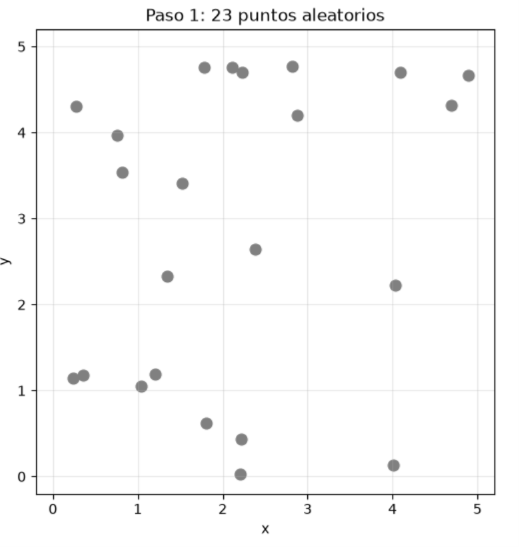

Luego, se preguntan cuales centroides se quieren usar, y ademas se pregunta si se quieren usar los puntos mas cercanos a la equidistancia entre centroides como puntos a analizar (Esto debido a que serian los puntos mas interezantes a ver) (Como tecnicamente esto no es valido, se pone como opcion decir que No)

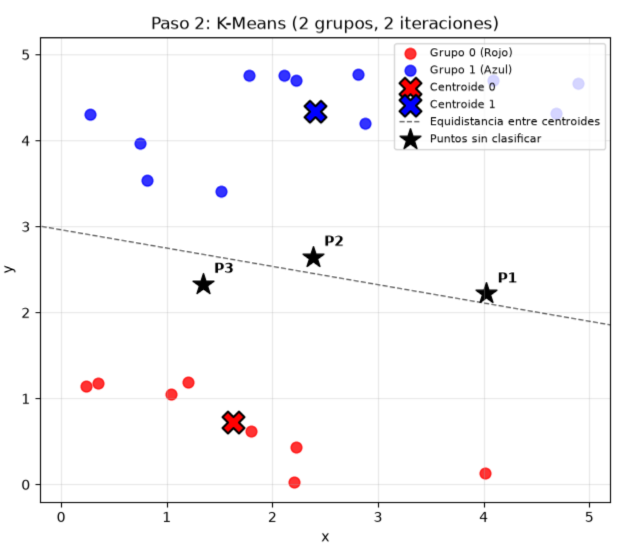

Luego, se hace la clasificacion con distintos Ks, mostrando cuales son los puntos tomados para seleccionar el grupo

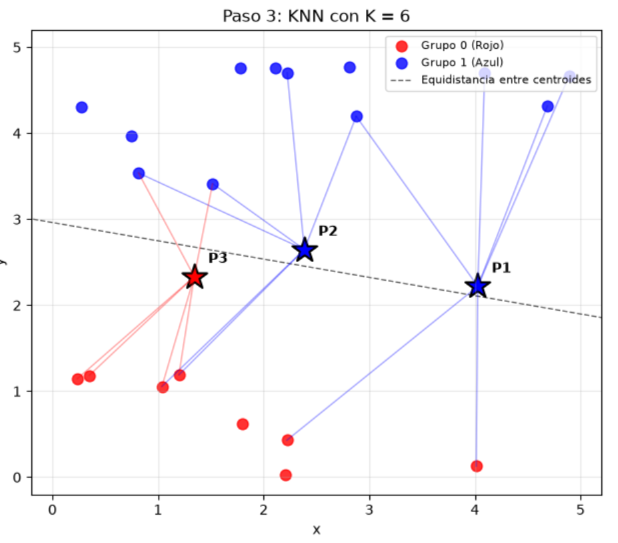

#### Prompt Utilizado
Eres un programador avanzado de Python, que toma una orientación de Programación orientada a objetos.

Tu deber es generar una implementación del algoritmo K Means usando numpy u otras librerías de calculo, pero No una biblioteca que tenga una implementación previa.
- Inicialmente genera un conjunto de 23 puntos que contengan coordenadas xy aleatorias con valores contenidos en el intervalo [0, 5]

- Luego, graficá los puntos en un grafico

- Con el algoritmo K-means, clasificá 20 de los 23 puntos en 2 grupos, y graficá el resultado asignando un color a cada uno (preferentemente Rojo y Azul).
	- Considerá preguntar los centroides iniciales por consola 
	- Para lograr una mejor visualización de el efecto de los K, implementá la opción de que los puntos a analizar sean los que están cercanos a equidistantes entre centroides. Tomalo como una pregunta Y/n, donde la opción predefinida es Sí

- Luego, añadí un breakpoint (preferentemente con un simple input)

- Después de ése breakpoint, Tomá los tres puntos restantes y clasifícalos en los grupos obtenidos anteriormente usando el algoritmo Knn. 
	- Utilizá una lista con 5 distintos valores de K, [1, 3, 5, 6, 9], indicando cuales son por consola, graficándolos e indicando que tipo de grupo se le asignó por consola, y añadiendo un break entre distintos K.
	- En caso de empate, gana la menor suma de distancias

4. La imagen mostrada abajo muestra una red de salas y cómo se comunican entre ellas. Implemente un algoritmo Q-Learning con un factor despreciativo $γ = 0.9$. La matriz de recompensas debe asignar un valor de 0 a cada camino accesible y un valor de 100 a caminos que lleven a la sala del tesoro.

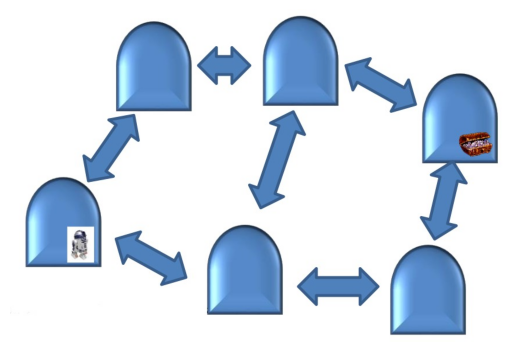

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1dkDruEIPa7f-BAmjI47TZl3bxaqYf6a9"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

&emsp;&emsp;4.1 Dibuje un diagrama con la asignación de recompensas correspondiente a cada estado.

&emsp;&emsp;4.2 Diseñe y muestre la matriz de recompensas.

&emsp;&emsp;4.3 Obtenga la matriz Q óptima, normalícela respecto al valor máximo encontrado y grafique la política obtenida en el diagrama mostrado inicialmente.

### Resolución

**Planteo.** Cada sala es un **estado** y cada flecha doble de la imagen es un pasillo que se puede recorrer en los dos sentidos. Una **acción** es "ir a la sala $a$", de modo que el estado siguiente es directamente $s' = a$ (entorno determinista). Numeramos las salas dejando el objetivo como último estado, igual que en el ejemplo de clase:

| Estado | Sala en la imagen | Se comunica con |
|:---:|---|---|
| **S0** | izquierda, donde está el robot (punto de partida) | S1, S3 |
| **S1** | arriba a la izquierda | S0, S2 |
| **S2** | arriba al centro | S1, S3, S5 |
| **S3** | abajo al centro | S0, S2, S4 |
| **S4** | abajo a la derecha | S3, S5 |
| **S5** | derecha, donde está el tesoro (objetivo) | S2, S4 |

La sala del tesoro es el **estado terminal**: cuando el robot entra, el episodio termina.

#### 4.1 Diagrama con la asignación de recompensas

![Diagrama de estados con la recompensa de cada movimiento](tp8_ej4_recompensas.png)

El número de cada flecha es la recompensa que recibe el agente al moverse en ese sentido:

- **100** (flecha gruesa): los dos pasillos que llevan a la sala del tesoro, S2 → S5 y S4 → S5.
- **0** (flecha doble): el resto de los pasillos, en cualquiera de los dos sentidos.
- **0** (flecha punteada): salir de la sala del tesoro. El camino existe, pero el agente no llega a usarlo porque el episodio termina al entrar.

Entre salas que no están comunicadas no hay flecha: ese movimiento no existe.

<details>
<summary>Código Mermaid del diagrama</summary>

```mermaid
flowchart LR
    S0(("S0<br/>robot"))
    S1(("S1"))
    S3(("S3"))
    S2(("S2"))
    S4(("S4"))
    S5(("S5<br/>tesoro"))

    S0 <-->|0| S1
    S0 <-->|0| S3
    S1 <-->|0| S2
    S3 <-->|0| S2
    S3 <-->|0| S4
    S2 ==>|100| S5
    S4 ==>|100| S5
    S2 <-.->|0| S5
    S4 <-.->|0| S5

    classDef sala fill:#DCE9F7,stroke:#2F6DB5,color:#14213D
    classDef inicio fill:#14213D,stroke:#14213D,color:#ffffff
    classDef tesoro fill:#F2B134,stroke:#8A5A00,color:#1A1F2B
    class S1,S2,S3,S4 sala
    class S0 inicio
    class S5 tesoro
    linkStyle 5,6 stroke:#C98500,stroke-width:4px
    linkStyle 7,8 marker-end:none
```

</details>

#### 4.2 Matriz de recompensas

La fila indica el estado actual $s$ y la columna la acción $a$, es decir, la sala a la que se quiere ir:

$$
R(s,a)=\begin{cases}
100 & \text{si hay pasillo de } s \text{ a } a \text{ y } a \text{ es la sala del tesoro}\\
0 & \text{si hay pasillo de } s \text{ a } a \text{ y } a \text{ es otra sala}\\
-1 & \text{si no hay pasillo de } s \text{ a } a
\end{cases}
$$

$$
R=\begin{array}{c|rrrrrr}
 & \text{S0} & \text{S1} & \text{S2} & \text{S3} & \text{S4} & \text{S5}\\ \hline
\text{S0} & -1 & 0 & -1 & 0 & -1 & -1\\
\text{S1} & 0 & -1 & 0 & -1 & -1 & -1\\
\text{S2} & -1 & 0 & -1 & 0 & -1 & 100\\
\text{S3} & 0 & -1 & 0 & -1 & 0 & -1\\
\text{S4} & -1 & -1 & -1 & 0 & -1 & 100\\
\text{S5} & -1 & -1 & 0 & -1 & 0 & -1
\end{array}
$$

El $-1$ no es una recompensa: solo marca los movimientos que no existen, como en el ejemplo de clase. La celda siguiente arma $R$ a partir de la lista de pasillos y la muestra.

Matriz de recompensas R  (fila = estado s, columna = acción a):

[[ -1   0  -1   0  -1  -1]
 [  0  -1   0  -1  -1  -1]
 [ -1   0  -1   0  -1 100]
 [  0  -1   0  -1   0  -1]
 [ -1  -1  -1   0  -1 100]
 [ -1  -1   0  -1   0  -1]]


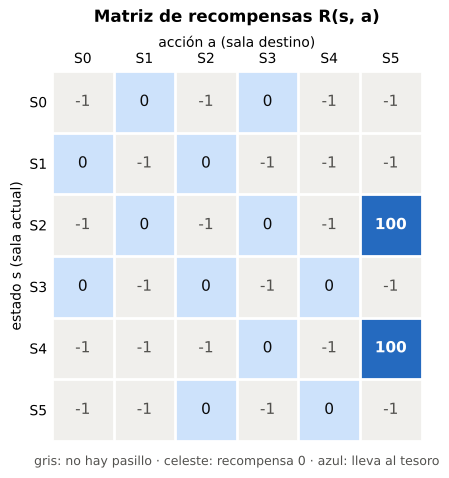

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ---------- Modelo: salas (estados) y pasillos ----------
N_SALAS = 6                         # salas S0 ... S5
INICIO, OBJETIVO = 0, 5             # S0: sala del robot · S5: sala del tesoro
PASILLOS = [(0, 1), (0, 3), (1, 2), (2, 3), (2, 5), (3, 4), (4, 5)]   # las 7 flechas dobles
SALAS = [f"S{i}" for i in range(N_SALAS)]

# ---------- 4.2 Matriz de recompensas R[s, a] ----------
# fila s = sala actual · columna a = sala a la que se va
R = np.full((N_SALAS, N_SALAS), -1)               # -1: no hay pasillo entre s y a
for i, j in PASILLOS:
    for s, a in ((i, j), (j, i)):                 # el pasillo vale en los dos sentidos
        R[s, a] = 100 if a == OBJETIVO else 0     # 100 si lleva al tesoro; si no, 0


def acciones(s):
    """Salas a las que se puede ir desde s (columnas de R distintas de -1)."""
    return np.flatnonzero(R[s] >= 0)


def mostrar_matriz(ax, M, titulo, destacar, nota):
    """Dibuja M como tabla: gris = sin pasillo, celeste = pasillo, azul = destacadas."""
    clase = np.where(R < 0, 0, np.where(destacar, 2, 1))
    ax.imshow(clase, cmap=ListedColormap(["#f0efec", "#cde2fb", "#256abf"]), vmin=0, vmax=2)
    for s in range(N_SALAS):
        for a in range(N_SALAS):
            ax.text(a, s, f"{M[s, a]:.3g}", ha="center", va="center", fontsize=11,
                    color=("#52514e", "#0b0b0b", "#ffffff")[clase[s, a]],
                    fontweight="bold" if clase[s, a] == 2 else "normal")
    ax.set_xticks(range(N_SALAS), SALAS)
    ax.set_yticks(range(N_SALAS), SALAS)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("acción a (sala destino)")
    ax.set_ylabel("estado s (sala actual)")
    ax.set_xticks(np.arange(N_SALAS + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(N_SALAS + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=2)      # separación entre celdas
    ax.tick_params(which="both", length=0)
    ax.spines[:].set_visible(False)
    ax.set_title(titulo, fontweight="bold", pad=10)
    ax.text(0.5, -0.04, nota, transform=ax.transAxes, ha="center", va="top",
            fontsize=9, color="#52514e")


print("Matriz de recompensas R  (fila = estado s, columna = acción a):\n")
print(R)

fig, ax = plt.subplots(figsize=(5.2, 4.8), facecolor="white")
mostrar_matriz(ax, R, "Matriz de recompensas R(s, a)", destacar=(R == 100),
               nota="gris: no hay pasillo · celeste: recompensa 0 · azul: lleva al tesoro")
plt.show()

#### 4.3 Matriz Q óptima, normalización y política

Cada vez que el agente pasa del estado $s$ al estado $s'$ con la acción $a$, Q-Learning actualiza un elemento de la tabla:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,\Big[\,R(s,a) + \gamma \max_{a'} Q(s',a') - Q(s,a)\Big]$$

Como el entorno es determinista usamos $\alpha = 1$ y queda la expresión vista en clase, con el factor de descuento del enunciado $\gamma = 0{,}9$:

$$Q(s,a) = R(s,a) + \gamma \max_{a'} Q(s',a')$$

El algoritmo es el de clase:

1. Inicializar $Q$ en cero.
2. En cada episodio, elegir un estado inicial al azar.
3. Mientras no se llegue a la sala del tesoro: elegir al azar una de las acciones posibles, actualizar $Q(s,a)$ y pasar al estado siguiente.
4. Repetir hasta que $Q$ deje de cambiar.

Las acciones se eligen al azar porque Q-Learning aprende la política óptima aunque el agente explore sin criterio: alcanza con que pase suficientes veces por todos los pares $(s,a)$.

Q deja de cambiar en el episodio 12 de 300
Residuo de la ecuación de Bellman: 0

Matriz Q óptima:
 [[  0.   81.    0.   81.    0.    0. ]
 [ 72.9   0.   90.    0.    0.    0. ]
 [  0.   81.    0.   81.    0.  100. ]
 [ 72.9   0.   90.    0.   90.    0. ]
 [  0.    0.    0.   81.    0.  100. ]
 [  0.    0.    0.    0.    0.    0. ]] 

Matriz Q normalizada (Q / 100):
 [[0.    0.81  0.    0.81  0.    0.   ]
 [0.729 0.    0.9   0.    0.    0.   ]
 [0.    0.81  0.    0.81  0.    1.   ]
 [0.729 0.    0.9   0.    0.9   0.   ]
 [0.    0.    0.    0.81  0.    1.   ]
 [0.    0.    0.    0.    0.    0.   ]]


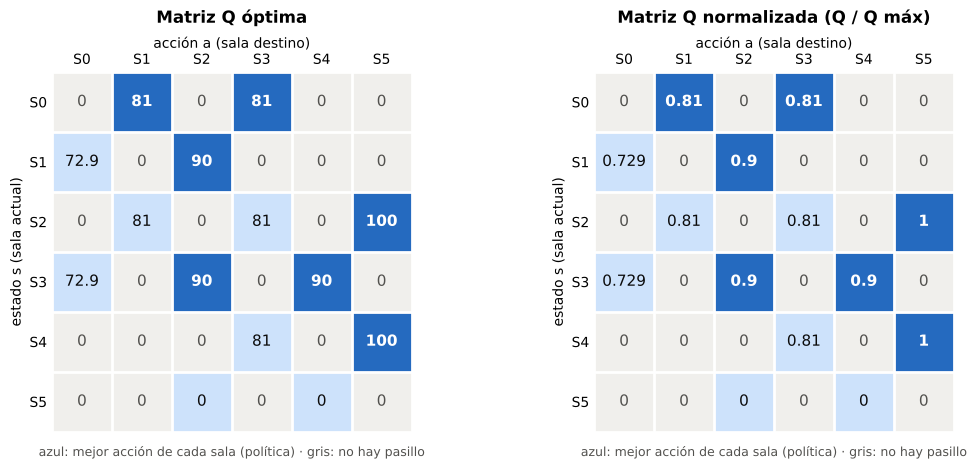

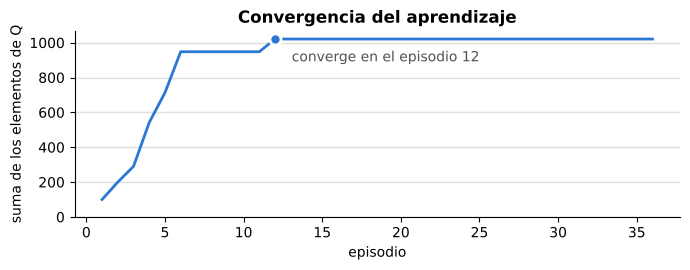

In [3]:
# ---------- 4.3 Q-Learning ----------
GAMMA = 0.9          # factor de descuento (enunciado)
ALPHA = 1.0          # tasa de aprendizaje (con 1 queda la fórmula vista en clase)
EPISODIOS = 300
rng = np.random.default_rng(0)       # semilla fija: resultado reproducible

Q = np.zeros((N_SALAS, N_SALAS))     # el agente arranca sin saber nada
suma_Q = []                          # suma de Q tras cada episodio (para ver la convergencia)
for episodio in range(EPISODIOS):
    s = rng.choice([e for e in range(N_SALAS) if e != OBJETIVO])   # estado inicial aleatorio
    while s != OBJETIVO:                                  # termina al llegar al tesoro
        a = rng.choice(acciones(s))                       # exploración: acción al azar
        s_sig = a                                         # ir a la sala a lleva a la sala a
        mejor_futuro = Q[s_sig, acciones(s_sig)].max()    # max Q(s', a')
        Q[s, a] += ALPHA * (R[s, a] + GAMMA * mejor_futuro - Q[s, a])
        s = s_sig
    suma_Q.append(Q.sum())

Q_norm = Q / Q.max()                 # normalización respecto del valor máximo

# Comprobación: Q es óptima si cumple la ecuación de Bellman  Q(s,a) = R(s,a) + γ·max Q(s',a')
residuo = max(abs(Q[s, a] - (R[s, a] + GAMMA * Q[a, acciones(a)].max()))
              for s in range(N_SALAS) if s != OBJETIVO for a in acciones(s))
episodio_conv = int(np.argmax(np.isclose(suma_Q, suma_Q[-1]))) + 1

np.set_printoptions(precision=3, suppress=True)
print(f"Q deja de cambiar en el episodio {episodio_conv} de {EPISODIOS}")
print(f"Residuo de la ecuación de Bellman: {residuo:.2g}\n")
print("Matriz Q óptima:\n", Q, "\n")
print(f"Matriz Q normalizada (Q / {Q.max():.0f}):\n", Q_norm)

# Mejor acción de cada fila (puede haber empates); S5 es terminal y no tiene acción
mejor = np.array([[R[s, a] >= 0 and s != OBJETIVO and np.isclose(Q[s, a], Q[s].max())
                   for a in range(N_SALAS)] for s in range(N_SALAS)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8), facecolor="white")
nota = "azul: mejor acción de cada sala (política) · gris: no hay pasillo"
mostrar_matriz(ax1, Q, "Matriz Q óptima", mejor, nota)
mostrar_matriz(ax2, Q_norm, "Matriz Q normalizada (Q / Q máx)", mejor, nota)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 2.8), facecolor="white")
ver = min(EPISODIOS, 3 * episodio_conv)        # alcanza con ver los primeros episodios
ax.plot(range(1, ver + 1), suma_Q[:ver], color="#2a78d6", linewidth=2)
ax.plot(episodio_conv, suma_Q[-1], "o", color="#2a78d6", markersize=8,
        markeredgecolor="white", markeredgewidth=2)
ax.annotate(f"converge en el episodio {episodio_conv}", (episodio_conv, suma_Q[-1]),
            xytext=(12, -16), textcoords="offset points", color="#52514e")
ax.set_xlabel("episodio")
ax.set_ylabel("suma de los elementos de Q")
ax.set_ylim(bottom=0)
ax.set_title("Convergencia del aprendizaje", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Política óptima (mejor acción en cada sala):
  S0 → ir a S1 o S3  (Q normalizado = 0.81)
  S1 → ir a S2       (Q normalizado = 0.90)
  S2 → ir a S5       (Q normalizado = 1.00)
  S3 → ir a S2 o S4  (Q normalizado = 0.90)
  S4 → ir a S5       (Q normalizado = 1.00)

Caminos óptimos desde la sala del robot (S0):
  S0 → S1 → S2 → S5   (3 movimientos)
  S0 → S3 → S2 → S5   (3 movimientos)
  S0 → S3 → S4 → S5   (3 movimientos)


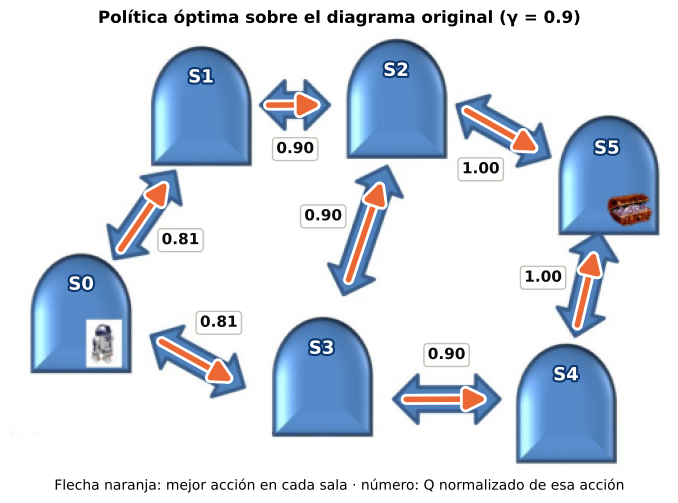

In [4]:
import matplotlib.patheffects as pe

# ---------- Política: en cada sala, la(s) acción(es) de mayor Q ----------
politica = {s: [int(a) for a in np.flatnonzero(mejor[s])]
            for s in range(N_SALAS) if s != OBJETIVO}


def caminos(s):
    """Todos los caminos óptimos desde s hasta el tesoro siguiendo la política."""
    if s == OBJETIVO:
        return [[s]]
    return [[s] + resto for a in politica[s] for resto in caminos(a)]


print("Política óptima (mejor acción en cada sala):")
for s, mejores in politica.items():
    destinos = " o ".join(SALAS[a] for a in mejores)
    print(f"  {SALAS[s]} → ir a {destinos:<8} (Q normalizado = {Q_norm[s, mejores[0]]:.2f})")
print(f"\nCaminos óptimos desde la sala del robot ({SALAS[INICIO]}):")
for c in caminos(INICIO):
    print("  " + " → ".join(SALAS[e] for e in c), f"  ({len(c) - 1} movimientos)")

# ---------- Política dibujada sobre el diagrama original ----------
# Posiciones medidas sobre la imagen del enunciado, como fracción (x / ancho, y / alto).
# SALAS_XY: dónde escribir el nombre de cada sala.
# PASILLOS_XY: extremos de cada flecha azul (junto a la sala i, junto a la sala j).
SALAS_XY = {0: (0.107, 0.573), 1: (0.289, 0.104), 2: (0.585, 0.089),
            3: (0.472, 0.718), 4: (0.843, 0.778), 5: (0.905, 0.265)}
PASILLOS_XY = {(0, 1): ((0.156, 0.516), (0.249, 0.314)),
               (0, 3): ((0.212, 0.687), (0.355, 0.805)),
               (1, 2): ((0.379, 0.166), (0.484, 0.165)),
               (2, 3): ((0.571, 0.303), (0.505, 0.596)),
               (2, 5): ((0.675, 0.164), (0.818, 0.284)),
               (3, 4): ((0.581, 0.832), (0.743, 0.831)),
               (4, 5): ((0.856, 0.690), (0.891, 0.469))}

tam = np.array(img.size)       # (ancho, alto) de img, la imagen del enunciado
fig, ax = plt.subplots(figsize=(8.5, 6), facecolor="white")
ax.imshow(img)
borde_blanco = [pe.withStroke(linewidth=8, foreground="white")]
for s, mejores in politica.items():
    for a in mejores:
        # flecha naranja dentro de la flecha azul del pasillo, en el sentido s → a
        p_i, p_j = PASILLOS_XY[(min(s, a), max(s, a))]
        p_s, p_a = (np.array(p) * tam for p in ((p_i, p_j) if s < a else (p_j, p_i)))
        ini, fin = p_s + 0.12 * (p_a - p_s), p_s + 0.88 * (p_a - p_s)
        ax.annotate("", xy=fin, xytext=ini,
                    arrowprops=dict(arrowstyle="-|>", color="#eb6834", linewidth=4,
                                    mutation_scale=28, shrinkA=0, shrinkB=0,
                                    path_effects=borde_blanco))
        # etiqueta con el Q normalizado, corrida hacia el centro de la figura
        normal = np.array([-(fin - ini)[1], (fin - ini)[0]]) / np.linalg.norm(fin - ini)
        centro = (ini + fin) / 2
        if np.dot(normal, tam / 2 - centro) < 0:
            normal = -normal
        ax.text(*(centro + 0.10 * tam[1] * normal), f"{Q_norm[s, a]:.2f}",
                ha="center", va="center", fontsize=11, fontweight="bold", color="#0b0b0b",
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#c3c2b7"))
for s, xy in SALAS_XY.items():
    ax.text(*(np.array(xy) * tam), SALAS[s], ha="center", va="center", fontsize=13,
            fontweight="bold", color="white",
            path_effects=[pe.withStroke(linewidth=3, foreground="#0d366b")])
ax.set_title(f"Política óptima sobre el diagrama original (γ = {GAMMA})", fontweight="bold")
ax.set_xlabel("Flecha naranja: mejor acción en cada sala · número: Q normalizado de esa acción")
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)
plt.show()

**Resultados**

- $Q$ deja de cambiar a los pocos episodios y cumple la ecuación de Bellman con residuo 0, así que es la matriz **óptima**. La fila de S5 queda en cero porque es el estado terminal.
- El valor máximo es 100, por lo que normalizar es dividir todo por 100.
- Cada valor normalizado es $\gamma^{\,d}$, donde $d$ es la cantidad de pasillos que quedan hasta el tesoro después de hacer el movimiento: $1$ si la acción entra al tesoro, $0{,}9$ si queda a un pasillo, $0{,}81$ a dos y $0{,}729$ a tres. Cada paso extra multiplica el valor por $0{,}9$; por eso el agente prefiere el camino más corto.

**Política obtenida** (acción de mayor $Q$ en cada sala):

| Sala | Mejor acción | $Q$ normalizado |
|:---:|---|:---:|
| S0 | ir a S1 o a S3 (empate) | 0,81 |
| S1 | ir a S2 | 0,90 |
| S2 | ir a S5 (tesoro) | 1,00 |
| S3 | ir a S2 o a S4 (empate) | 0,90 |
| S4 | ir a S5 (tesoro) | 1,00 |

Desde la sala del robot hay **tres caminos óptimos**, todos de 3 movimientos: S0 → S1 → S2 → S5, S0 → S3 → S2 → S5 y S0 → S3 → S4 → S5. La política no es única porque en S0 y en S3 hay dos acciones con el mismo valor.

**Sobre el estado objetivo.** En el ejemplo de clase el objetivo tenía un lazo sobre sí mismo con recompensa 100. En la imagen de este ejercicio ese lazo no está y el enunciado solo asigna 100 a los caminos que llevan al tesoro, así que tomamos S5 como estado terminal. Si se agregara el lazo, $Q$ solo cambiaría de escala (el máximo pasaría de 100 a $100/(1-\gamma) = 1000$): la matriz normalizada de las salas S0 a S4 y la política serían las mismas.

### Prompt utilizado

>Actúa como un experto en Inteligencia Artificial y Sistemas de Control. Necesito resolver un problema de Aprendizaje por Refuerzo (Reinforcement Learning) utilizando el algoritmo Q-Learning. 

Como estudiante de Ingeniería Mecatrónica, valoro la precisión técnica y un enfoque puramente analítico. Antes de dar la solución numérica, prioriza el "por qué": explica la lógica matemática del Proceso de Decisión de Markov (MDP) y desglosa la Ecuación de Bellman. Cuando realices el desarrollo matemático, hazlo paso por paso. Si utilizas fórmulas auxiliares, inclúyelas y explica cómo se llega a cada una. Analiza también cómo la actualización del valor en un estado afecta a los estados adyacentes del sistema. No simplifiques las explicaciones técnicas.

**Definición del Sistema (Topología de la red de salas):**
El sistema se compone de 6 estados (salas) definidos de la siguiente manera:
*   **Estado 0:** Sala inferior izquierda (posición inicial del agente).
*   **Estado 1:** Sala superior izquierda.
*   **Estado 2:** Sala inferior central.
*   **Estado 3:** Sala superior central.
*   **Estado 4:** Sala inferior derecha.
*   **Estado 5:** Sala superior derecha (Sala del tesoro / Estado objetivo).

Las conexiones bidireccionales entre las salas (caminos accesibles) son:
*   0 ↔ 1
*   0 ↔ 2
*   1 ↔ 3
*   2 ↔ 3
*   2 ↔ 4
*   3 ↔ 5
*   4 ↔ 5

**Condiciones del Ejercicio:**
*   Implementar un algoritmo Q-Learning.
*   Factor despreciativo (descuento): $\gamma = 0.9$.
*   La matriz de recompensas debe asignar un valor de $0$ a cada camino accesible y un valor de $100$ a las transiciones que lleven directamente a la sala del tesoro (Estado 5).
*   Las transiciones no posibles deben indicarse como nulas o con un valor de penalización (ej. $-1$).

**Resolución Requerida:**
4.1. Define y representa el diagrama de estados con la asignación de recompensas correspondiente a cada transición.
4.2. Diseña y muestra la matriz de recompensas $R$ (matriz de 6x6).
4.3. Obtenga la matriz $Q$ óptima. Muestra el desarrollo matemático de las iteraciones necesarias para demostrar cómo se propagan los valores a través de la ecuación de Bellman desde el estado objetivo hacia atrás. Posteriormente, muestra la matriz $Q$ final, normalícela respecto al valor máximo encontrado y define claramente la política óptima $\pi(s)$ obtenida para graficarla sobre el diagrama inicial.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2017) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)